In [1]:
import typing as t
from pathlib import Path

import polars as pl
import matplotlib.pyplot as plt

from processing.orderbook import OrderBookDataset, OrderBookDataProcessor
from processing.trades import TradesDataset

ROOT_DIR: Path = Path.cwd().parent.parent
DATA_DIR: Path = ROOT_DIR / "data"
ORDERBOOK_DATA_FILEPATH: Path = DATA_DIR / "round-0/day-1/prices_round_0_day_-1.csv"
TRADES_DATA_FILEPATH: Path = DATA_DIR / "round-0/day-1/trades_round_0_day_-1.csv"

NUM_QUOTES: t.Final[int] = 3

orderbook_data: OrderBookDataset = OrderBookDataset(ORDERBOOK_DATA_FILEPATH)
trades_data: TradesDataset = TradesDataset(TRADES_DATA_FILEPATH)

ModuleNotFoundError: No module named 'processing'

In [2]:
orderbook_products: list[str] = orderbook_data.products()
trades_products: list[str] = trades_data.products()

print(f"Orderbook products: {', '.join(orderbook_products)}")
print(f"Trades products: {', '.join(trades_products)}")

Orderbook products: EMERALDS, TOMATOES
Trades products: TOMATOES, EMERALDS


In [4]:
tomatoes_orderbook: OrderBookDataProcessor = (
    orderbook_data
    .for_product("TOMATOES")
    .clean()
    .add_microstructure_features()
    .add_price_features()
    .add_depth_features()
    .build()
)

emeralds_orderbook: OrderBookDataProcessor = (
    orderbook_data
    .for_product("EMERALDS")
    .clean()
    .add_microstructure_features()
    .add_price_features()
    .add_depth_features()
    .build()
)

In [5]:
tomatoes_trades: pl.DataFrame = (
    trades_data
    .for_product("TOMATOES")
    .clean()
    .build()
)

emeralds_trades: pl.DataFrame = (
    trades_data
    .for_product("EMERALDS")
    .clean()
    .build()
)

In [6]:
def join_midprice_trade_price(
    product: str,
    orderbook: pl.dataframe,
    trades: pl.DataFrame
    ) -> pl.DataFrame:
    mid_prices = orderbook.select([
        "timestamp",
        pl.col("mid_price").alias(f"{product}_mid_price")
    ])

    traded_prices = trades.select([
        "timestamp",
        pl.col("price").alias(f"{product}_traded_price")
    ])

    return mid_prices.join(
        traded_prices,
        on="timestamp",
        how="full",
        coalesce = True
    )

tomatoes_joint: pl.DataFrame = join_midprice_trade_price("TOMATOES", tomatoes_orderbook, tomatoes_trades)
emeralds_joint: pl.DataFrame = join_midprice_trade_price("EMERALDS", emeralds_orderbook, emeralds_trades)


In [7]:
import pandas as pd

tomatoes_joint_pd = tomatoes_joint.to_pandas()
tomatoes_joint_pd.plot()

ModuleNotFoundError: No module named 'pyarrow'

In [8]:
tomatoes_joint

timestamp,TOMATOES_mid_price,TOMATOES_traded_price
i64,f64,f64
0,5006.0,null
100,5006.5,null
200,5006.5,null
300,5007.0,null
400,5007.0,null
…,…,…
999500,4959.0,null
999600,4959.0,null
999700,4956.5,null


In [9]:
emeralds_joint

timestamp,EMERALDS_mid_price,EMERALDS_traded_price
i64,f64,f64
0,10000.0,null
100,10000.0,null
200,10000.0,null
300,10000.0,null
400,10000.0,null
…,…,…
999500,10000.0,null
999600,10000.0,null
999700,10000.0,null


In [10]:
emeralds_joint

timestamp,EMERALDS_mid_price,EMERALDS_traded_price
i64,f64,f64
0,10000.0,null
100,10000.0,null
200,10000.0,null
300,10000.0,null
400,10000.0,null
…,…,…
999500,10000.0,null
999600,10000.0,null
999700,10000.0,null


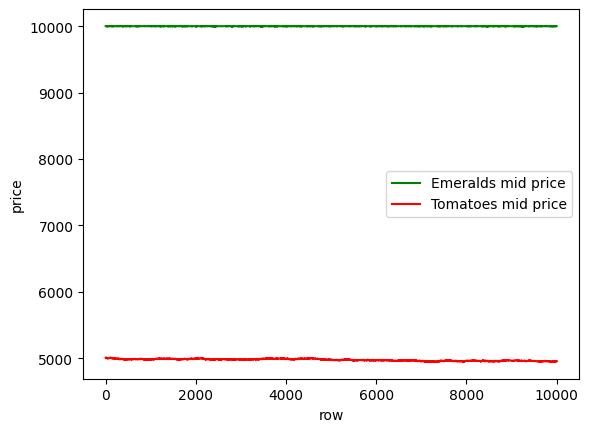

In [11]:
plt.plot(
    emeralds_joint.get_column("EMERALDS_mid_price"),
    color="green",
    label="Emeralds mid price"
)
plt.plot(
    tomatoes_joint.get_column("TOMATOES_mid_price"),
    color="red",
    label="Tomatoes mid price"
)

plt.gca().yaxis.get_major_formatter().set_useOffset(False)
plt.legend()
plt.xlabel("row")
plt.ylabel("price")
plt.show()

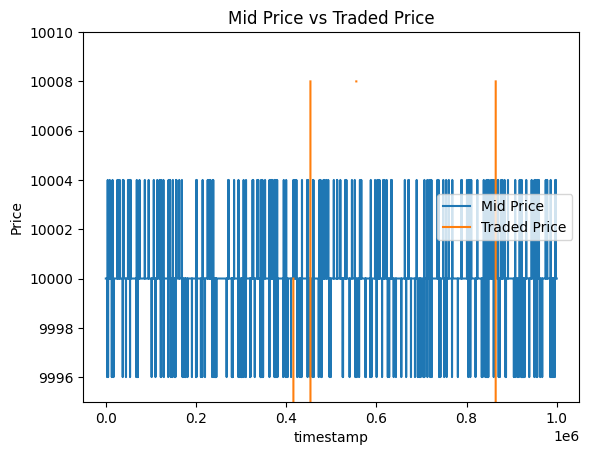

In [12]:
plt.plot(emeralds_joint["timestamp"], emeralds_joint["EMERALDS_mid_price"], label="Mid Price")
plt.plot(emeralds_joint["timestamp"], emeralds_joint["EMERALDS_traded_price"], label="Traded Price")
plt.gca().yaxis.get_major_formatter().set_useOffset(False)

plt.ylim((9995, 10010))
plt.xlabel("timestamp")
plt.ylabel("Price")
plt.title("Mid Price vs Traded Price")
plt.legend()

plt.show()